{'topic': '猫', 'joke': '一只猫走进了一家狗主题的酒吧，狗老板说：“对不起，我们这里不接待猫。”  \n猫淡定地舔了舔爪子：“我不是猫，我是汪星人派来的卧底，专门来查你们有没有偷卖猫粮。”  \n狗老板愣了：“那你到底想喝什么？”  \n猫：“给我来碗牛奶，加条小鱼干。”', 'story': '# 猫的报恩\n\n巷子口有只流浪猫，灰白相间，瘦得肋骨根根分明。\n\n我常在加班回来的深夜见到它。它蹲在路灯下，眯着眼睛看我走近，不跑，也不叫，像一尊小小的雕像。\n\n起初我只是把剩饭放在墙角。后来买了猫粮，放在固定的碗里。慢慢地，它允许我伸手摸摸它的头，但它从不跟我回家。\n\n有一天我加班到凌晨两点，下着雨，心情差到了极点。走到巷口，发现那个碗被翻倒了，猫也不在。我蹲下来收拾碗，突然看见碗下面压着一样东西——一枚干净的、闪着光的白色纽扣。\n\n那是它从我衬衫上叼走的那一颗。三天前掉的，我没找到，却忘了。\n\n猫不知从哪里钻出来，浑身湿透，把纽扣往我脚边又推了推。\n\n然后转身，消失在雨里。\n\n从那以后，我再也没见过它。\n\n但每到下雨天，我都会去巷口看一看。碗还在，装满的是我欠它的一句：谢谢。', 'poem': '## 《夜巡者》\n\n九次坠落之后\n它们学会了用月光\n缝合脊椎的断痕\n\n当绒毛擦过墙角\n夜被折叠成\n纸船的形状\n在寂静里浮沉\n\n偶尔有爪印\n在未干的梦里\n写下占卜的符号\n\n请原谅那声\n惊醒黎明的叫唤\n——不过是\n将月光\n分发给路人', 'combined_output': '下面是一个关于“猫”的故事、笑话和诗歌！\n\n故事：\n# 猫的报恩\n\n巷子口有只流浪猫，灰白相间，瘦得肋骨根根分明。\n\n我常在加班回来的深夜见到它。它蹲在路灯下，眯着眼睛看我走近，不跑，也不叫，像一尊小小的雕像。\n\n起初我只是把剩饭放在墙角。后来买了猫粮，放在固定的碗里。慢慢地，它允许我伸手摸摸它的头，但它从不跟我回家。\n\n有一天我加班到凌晨两点，下着雨，心情差到了极点。走到巷口，发现那个碗被翻倒了，猫也不在。我蹲下来收拾碗，突然看见碗下面压着一样东西——一枚干净的、闪着光的白色纽扣。\n\n那是它从我衬衫上叼走的那一颗。三天前掉的，我没找到，却忘了。\n\n猫不知从哪里钻出来，浑身湿透，把纽

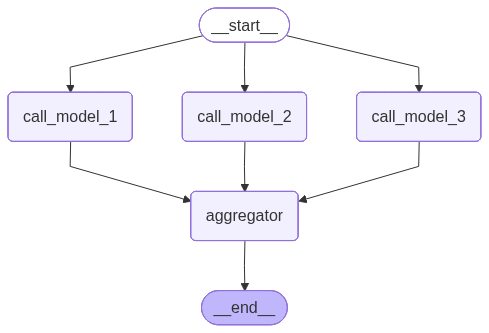

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

# 节点
def call_model_1(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短的笑话")]
    )
    return {"joke": msg.content}

def call_model_2(state: OverAllState) -> OverAllState:
    """第二次调用大模型，生成故事"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于“{state['topic']}”的简短的故事")]
    )
    return {"story": msg.content}

def call_model_3(state: OverAllState) -> OverAllState:
    """第三次调用大模型，生成诗歌"""

    msg = model.invoke(
        [HumanMessage(content=f"写一首关于“{state['topic']}”的简短的诗")]
    )
    return {"poem": msg.content}

def aggregator(state: OverAllState) -> OverAllState:
    """将笑话、故事和诗歌合并为单一输出"""

    combined = f"下面是一个关于“{state['topic']}”的故事、笑话和诗歌！\n\n"
    combined += f"故事：\n{state['story']}\n\n"
    combined += f"笑话：\n{state['joke']}\n\n"
    combined += f"诗歌：\n{state['poem']}"
    return {"combined_output": combined}

# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("call_model_1", call_model_1)
builder.add_node("call_model_2", call_model_2)
builder.add_node("call_model_3", call_model_3)
builder.add_node("aggregator", aggregator)

# 添加边，连接各个节点
builder.add_edge(START, "call_model_1")
builder.add_edge(START, "call_model_2")
builder.add_edge(START, "call_model_3")
builder.add_edge(["call_model_1", "call_model_2", "call_model_3"], "aggregator")
builder.add_edge("aggregator", END)

graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

from IPython.display import display
display(graph)